#  Analisis Indeks Standar Pencemar Udara (ISPU) DKI Jakarta (2010 - 2025)

## BAGIAN 1 — BUSINESS UNDERSTANDING


### 1.1 Latar Belakang

**ISPU (Indeks Standar Pencemar Udara)** adalah indeks yang digunakan untuk menggambarkan kondisi mutu udara ambien di lokasi dan waktu tertentu yang didasarkan kepada dampak terhadap kesehatan manusia, nilai estetika, dan makhluk hidup lainnya.

ISPU pertama kali ditetapkan melalui **Keputusan Menteri Negara Lingkungan Hidup Nomor: KEP-45/MENLH/10/1997** dan diperbarui melalui **Peraturan Menteri Lingkungan Hidup dan Kehutanan Nomor P.14/MENLH/2020**.

#### Konteks DKI Jakarta
- Jakarta adalah **ibu kota Indonesia** dengan populasi lebih dari **10 juta jiwa** (dan 30 juta di Jabodetabek)
- Jakarta secara konsisten masuk dalam daftar kota dengan **kualitas udara terburuk di Asia Tenggara**
- Polusi udara berdampak pada **kesehatan masyarakat, produktivitas ekonomi, pariwisata, dan citra kota**
- Pemerintah DKI Jakarta mengoperasikan **5 stasiun pemantau kualitas udara** real-time
![image.png](attachment:image.png)
#### Parameter Polutan yang Diukur

| Parameter | Nama Lengkap | Sumber Utama |
|-----------|-------------|--------------|
| **PM2.5** | Partikel Halus (≤2.5 µm) | Kendaraan bermotor, industri, pembakaran |
| **PM10** | Partikel Kasar (≤10 µm) | Debu konstruksi, jalan, industri |
| **SO₂** | Sulfur Dioksida | Pembakaran bahan bakar fosil, industri |
| **CO** | Karbon Monoksida | Kendaraan bermotor, pembakaran tidak sempurna |
| **O₃** | Ozon Troposferik | Reaksi fotokimia (polutan sekunder) |
| **NO₂** | Nitrogen Dioksida | Kendaraan bermotor, pembangkit listrik |

#### Lokasi 5 Stasiun Pemantau

| Kode | Lokasi | Wilayah | Karakteristik |
|------|--------|---------|---------------|
| DKI1 | Bunderan HI | Jakarta Pusat | Kawasan komersial & traffic tinggi |
| DKI2 | Kelapa Gading | Jakarta Utara | Kawasan permukiman & komersial |
| DKI3 | Jagakarsa | Jakarta Selatan | Relatif hijau, residential |
| DKI4 | Lubang Buaya | Jakarta Timur | Kawasan perumahan & industri |
| DKI5 | Kebon Jeruk | Jakarta Barat | Kawasan mixed-use |

### 1.2 Kategori ISPU & Rentang Nilai

Berdasarkan PerMen LHK No. P.14/MENLH/2020:

| Nilai ISPU | Kategori | Warna | Dampak Kesehatan |
|-----------|----------|-------|-----------------|
| 0 – 50 | **BAIK** |  Hijau | Tidak memberikan efek negatif |
| 51 – 100 | **SEDANG** |  Kuning | Tidak berpengaruh pada kesehatan manusia dan hewan, tetapi berpengaruh pada tumbuhan sensitif |
| 101 – 199 | **TIDAK SEHAT** | Oranye | Bersifat merugikan pada manusia, hewan, dan tumbuhan |
| 200 – 299 | **SANGAT TIDAK SEHAT** | Merah | Kualitas udara yang dapat meningkatkan risiko kesehatan pada manusia |
| 300+ | **BERBAHAYA** | Ungu | Tingkat kualitas udara yang berbahaya secara umum |

### 1.3 Problem Statement & Tujuan Analisis

#### Problem Statement
> *"Bagaimana tren kualitas udara DKI Jakarta selama 15 tahun terakhir (2010–2025), faktor apa yang paling berkontribusi terhadap pencemaran, dan bagaimana distribusi kondisi udara antar wilayah serta waktu?"*

#### Tujuan Analisis (Business Goals → Analytic Goals)

| # | Business Goal | Analytic Goal | Metode |
|---|--------------|---------------|--------|
| 1 | Memahami tren kualitas udara jangka panjang | Analisis time series ISPU per tahun | Trend line, rolling mean |
| 2 | Identifikasi polutan dominan | Analisis distribusi parameter `critical` | Frequency analysis, bar chart |
| 3 | Pemetaan wilayah paling tercemar | Perbandingan antar stasiun | Box plot, heatmap |
| 4 | Pola musiman & harian | Deteksi seasonality | Heatmap bulan/musim |
| 5 | Kualitas data untuk modeling | Audit missing values & anomali | Missingness matrix |
| 6 | Baseline untuk prediksi / klasifikasi | EDA fitur target `categori` | Class distribution |

#### Key Analytic Questions
1. Apakah kualitas udara Jakarta membaik atau memburuk dari 2010 ke 2025?
2. Bulan/musim apa yang memiliki kualitas udara terburuk?
3. Stasiun mana yang secara konsisten mencatat nilai ISPU tertinggi?
4. Polutan apa yang paling sering menjadi pencemar kritis?
5. Seberapa besar proporsi hari dengan kategori "Tidak Sehat" atau lebih buruk?
6. Apakah ada korelasi antar polutan?
7. Bagaimana distribusi nilai outlier pada setiap parameter?

### 1.4 Stakeholder & Implikasi

| Stakeholder | Kebutuhan | Output dari Analisis |
|------------|----------|----------------------|
| **Dinas LHK DKI Jakarta** | Monitoring & kebijakan | Tren, hotspot lokasi, pola temporal |
| **Kemenkes RI** | Peringatan dini kesehatan | Proporsi hari berbahaya, threshold |
| **Masyarakat Umum** | Informasi kualitas udara | Dashboard, kategori harian |
| **Peneliti/Akademisi** | Baseline dataset | Statistik deskriptif, korelasi |
| **Media & Jurnalis** | Narasi data | Insight utama, visualisasi |
| **Pemerintah Kota** | Evaluasi kebijakan (ganjil-genap, PPKM) | Tren tahunan, efek COVID-19 2020 |

## Install Library & Import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print(" Semua library berhasil diimport!")


 Semua library berhasil diimport!


## 2. Load Data 

In [78]:
DATA_PATH = 'data.csv'  

df = pd.read_csv(DATA_PATH)

print(f"Dataset berhasil dimuat sebagai berikut\n")
print(f"Jumlah baris  : {df.shape[0]}")
print(f"Jumlah kolom  : {df.shape[1]}")
print()
df.head(130)


Dataset berhasil dimuat sebagai berikut

Jumlah baris  : 5538
Jumlah kolom  : 11



,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK
...,...,...,...,...,...,...,...,...,...,...,...
125,2010-05-06,DKI1 (Bunderan HI),NaN,53.0,19.0,25.0,21.0,11.0,53.0,PM10,SEDANG
126,2010-05-07,DKI1 (Bunderan HI),NaN,67.0,19.0,33.0,33.0,16.0,67.0,PM10,SEDANG
127,2010-05-08,DKI1 (Bunderan HI),NaN,57.0,16.0,24.0,26.0,9.0,57.0,PM10,SEDANG
128,2010-05-09,DKI1 (Bunderan HI),NaN,NaN,16.0,28.0,51.0,16.0,51.0,O3,SEDANG


Insight :
1. **Pola Sensor yang Tidak Stabil (Missing Values):** 
   Kolom PM2.5 secara konsisten kosong (`NaN`) dari Januari hingga Mei, menandakan alat ukur tersebut kemungkinan belum terpasang di tahun 2010. Selain itu, pada tanggal 9 dan 10 Mei, data PM10 tiba-tiba ikut kosong, yang mengindikasikan adanya hari-hari di mana sensor PM10 rusak atau sedang dalam masa perbaikan (maintenance).

2. **Pergeseran Polutan Paling Berbahaya (Kritis):**
   Pada awal tahun (Januari), partikel debu (PM10) mendominasi sebagai penyumbang terbesar polusi harian. Namun, saat memasuki bulan Mei, Ozon (O3) melonjak tajam hingga menyentuh angka 75.0 dan mengambil alih peran PM10 sebagai polutan paling kritis penyumbang status polusi.

3. **Aturan Baku Penentuan Kategori Udara:**
   Terlihat jelas bahwa kolom `categori` (Target) 100% diputuskan oleh angka pada kolom `max`. Terdapat ambang batas yang tegas: selama polutan tertinggi (`max`) berada di bawah angka 50, kualitas udara berstatus **"BAIK"**. Namun begitu menyentuh angka 50 ke atas, statusnya otomatis berubah menjadi **"SEDANG"**.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   5538 non-null   str    
 1   stasiun   5537 non-null   str    
 2   pm25      1516 non-null   float64
 3   pm10      5223 non-null   float64
 4   so2       5408 non-null   float64
 5   co        5450 non-null   float64
 6   o3        5434 non-null   float64
 7   no2       5432 non-null   float64
 8   max       5537 non-null   float64
 9   critical  5534 non-null   str    
 10  categori  5538 non-null   str    
dtypes: float64(7), str(4)
memory usage: 476.1 KB


Inshigt :

1. **Buang Kolom PM2.5:**
   Hampir 73% data pada kolom `pm25` kosong (hanya terisi 1.516 dari 5.538). 

2. **Isi Data Bolong (Imputasi) pada Polutan Lainnya:**
   Kolom `pm10`, `so2`, `co`, `o3`, dan `no2` memiliki beberapa ratus data kosong. 

3. **Perbaiki Tipe Data Tanggal:**
   Kolom `tanggal` saat ini masih terbaca sebagai teks biasa (`str`). 

In [74]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tanggal,5538,5538,2010-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stasiun,5537,5,DKI4 (Lubang Buaya),1674,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pm25,1516.0,NaN,NaN,NaN,89.742084,26.61596,10.0,71.0,90.0,107.0,287.0
pm10,5223.0,NaN,NaN,NaN,56.407046,20.010963,2.0,45.0,57.0,67.0,187.0
so2,5408.0,NaN,NaN,NaN,22.436206,15.450584,0.0,10.0,18.0,32.0,112.0
co,5450.0,NaN,NaN,NaN,20.422752,11.966246,0.0,12.0,18.0,26.0,119.0
o3,5434.0,NaN,NaN,NaN,77.465771,51.798101,4.0,36.0,69.0,103.0,314.0
no2,5432.0,NaN,NaN,NaN,14.349227,10.051099,1.0,8.0,12.0,18.0,202.0
max,5537.0,NaN,NaN,NaN,97.62579,40.955382,0.0,70.0,90.0,114.0,314.0
critical,5534,6,O3,2970,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Insight : 

1. **Ozon (O3) adalah Sumber Polusi Utama:** 
   Ozon memiliki nilai maksimum paling tinggi (314.0) dibandingkan polutan lain. Hal ini diperkuat oleh kolom `critical`, di mana O3 menjadi polutan paling sering yang membuat kualitas udara memburuk (muncul 2.970 kali sebagai polutan paling kritis).

2. **Kualitas Udara Jakarta Didominasi Status "SEDANG":** 
   Dari total 5.538 observasi harian, status kualitas udara (`categori`) paling sering (Modus) berada pada level **SEDANG** yang terjadi sebanyak 3.187 hari. Ini menunjukkan udara secara umum kurang ideal meski belum mencapai level sangat berbahaya setiap saat.

3. **Indikasi Lonjakan Polusi Ekstrem (Outlier):** 
   Ada jarak yang sangat jauh antara nilai batas 75% data dengan nilai Tertinggi (Max) pada beberapa polutan. Misalnya pada `o3`, 75% datanya berada di angka 103 ke bawah, namun nilai maksimumnya tiba-tiba melonjak hingga **314**. Ini menandakan adanya beberapa hari tertentu yang mengalami "bencana" atau lonjakan polusi yang sangat ekstrem (*outlier*).

## 3. Exploratory Data Analysis (EDA) dan Data Cleaning

### 3.1 EDA : Cek Missing Value

In [80]:
missing = df.isnull().sum().reset_index()
missing.columns = ['Kolom', 'Jumlah Missing']
missing['Persentase (%)'] = (missing['Jumlah Missing'] / len(df) * 100).round(2)
missing = missing.sort_values('Jumlah Missing', ascending=False)
print(missing.to_string(index=False))


   Kolom  Jumlah Missing  Persentase (%)
    pm25            4022           72.63
    pm10             315            5.69
     so2             130            2.35
     no2             106            1.91
      o3             104            1.88
      co              88            1.59
critical               4            0.07
     max               1            0.02
 stasiun               1            0.02
 tanggal               0            0.00
categori               0            0.00


Insight : 
1. **Kerusakan Fatal pada Data PM2.5 (Harus Di-drop):** 
   Kolom `pm25` kehilangan hampir seluruh datanya (**72.63%** kosong). Dalam praktiknya, jika data hilang di atas 50%, kolom tersebut sudah tidak bisa diselamatkan karena jika dipaksakan diisi (imputasi) akan merusak keaslian pola data. Solusinya: **Drop/hapus seluruh kolom PM2.5**. (menyebabkan data imbalance)

2. **Kekosongan Ringan pada 5 Polutan Lainnya (Bisa Diimputasi):** 
   Polutan utama lainnya seperti `pm10`, `so2`, `no2`, `o3`, dan `co` hanya memiliki data hilang berskala kecil, yaitu di bawah **6%**. Data ini masih sangat berharga dan layak dipertahankan. Solusinya: **Isi data yang kosong** menggunakan nilai *Median* atau *Mean* (Imputasi) agar Anda tidak membuang terlalu banyak baris data.

3. **Data Identitas Nyaris Sempurna (Cukup Hapus Barisnya):** 
   Kolom penting seperti `stasiun`, `max`, dan `critical` nyaris lengkap 100% (persentase kosongnya di bawah **0.1%** atau hanya 1-4 baris saja). Mengingat jumlahnya yang sangat sedikit dan sepele, solusinya: **Cukup buang/drop baris (rows)** yang data stasiun/max-nya kosong tersebut tanpa perlu khawatir mengurangi kualitas keseluruhan dataset.

### 3.2 Data Cleaning : Mengatasi Missing Value

In [83]:
df_clean = df.copy()

In [84]:
# Drop/hapus seluruh kolom PM2.5
df_clean = df_clean.drop(columns=['pm25'])

In [86]:
# Imputasi (Isi data kosong) pada 5 polutan menggunakan nilai Median
polutan_cols = ['pm10', 'so2', 'no2', 'o3', 'co']

for col in polutan_cols:
    nilai_median = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(nilai_median)

In [87]:
df_clean = df_clean.dropna(subset=['stasiun', 'max', 'critical'])

### 3.3 EDA : Cek Missing Value sesudah data di cleaning

In [88]:
print("Jumlah Missing Values Setelah Cleaning:")
print(df_clean.isnull().sum())
print(f"\nUkuran data setelah dibersihkan: {df_clean.shape}")

Jumlah Missing Values Setelah Cleaning:
tanggal     0
stasiun     0
pm10        0
so2         0
co          0
o3          0
no2         0
max         0
critical    0
categori    0
dtype: int64

Ukuran data setelah dibersihkan: (5533, 10)


### 3.2 EDA : Distribusi Kategori Kualitas Udara (perhari)

In [103]:
cat_counts = df_clean['categori'].value_counts()
cat_pct = (cat_counts / len(df_clean) * 100).round(2)

print("TOTAL HARI & PROPORSI PERSENTASE KATEGORI")
print("-" * 50)

for cat in cat_counts.index:
    jumlah = cat_counts[cat]
    persen = cat_pct[cat]
    print(f"{cat:<20} : {jumlah} Hari \t({persen}%)")

print("-" * 50)
print(f"Total Keseluruhan    : {len(df_clean)} Hari")


TOTAL HARI & PROPORSI PERSENTASE KATEGORI
--------------------------------------------------
SEDANG               : 3186 Hari 	(57.58%)
TIDAK SEHAT          : 1827 Hari 	(33.02%)
BAIK                 : 316 Hari 	(5.71%)
SANGAT TIDAK SEHAT   : 203 Hari 	(3.67%)
BERBAHAYA            : 1 Hari 	(0.02%)
--------------------------------------------------
Total Keseluruhan    : 5533 Hari


Insight : 
1. **Kualitas Udara Didominasi Level "Kurang Ideal":** 
   Lebih dari **90%** (gabungan 57.58% "Sedang" dan 33.02% "Tidak Sehat") hari-hari di Jakarta berada pada tingkat polusi menengah hingga buruk. Ini menunjukkan bahwa kualitas udara secara umum terus-menerus berada di batas ambang waspada dan kurang ramah bagi pernapasan jangka panjang.

2. **Hari dengan Udara "BAIK" Sangat Langka:** 
   Dari 5.533 hari pemantauan, warga hanya merasakan udara yang berstatus "BAIK" selama **316 hari saja (sekitar 5.71%)**. Hal ini menyoroti tingginya tingkat polusi harian dan betapa sulitnya mendapatkan kondisi udara yang benar-benar bersih secara optimal.

3. **Ketidakseimbangan Data yang Ekstrem (Class Imbalance):** 
   Kategori "BERBAHAYA" hanya terjadi **1 hari (0.02%)** dalam belasan tahun pencatatan. Untuk keperluan algoritma *Machine Learning*, ini adalah temuan yang sangat krusial karena jumlah 1 data terlalu sedikit untuk dipelajari oleh model dan justru akan membuat program *error*.Sehingga  Kelas ini sebaiknya di-drop atau digabungkan ke "SANGAT TIDAK SEHAT".

### 3.3 Data clean : Mengemplokan class milik BERBAHAYA ke SANGAT TIDAK SEHAT (Class Imbalance)

In [106]:
df_clean = df_clean[df_clean['categori'] != 'BERBAHAYA']
print("Jumlah 'BERBAHAYA' sekarang:", (df_clean['categori'] == 'BERBAHAYA').sum())
print("Total data tersisa:", len(df_clean), "baris")


Jumlah 'BERBAHAYA' sekarang: 0
Total data tersisa: 5532 baris


### 3.4 EDA : Distribusi Kategori per Stasiun

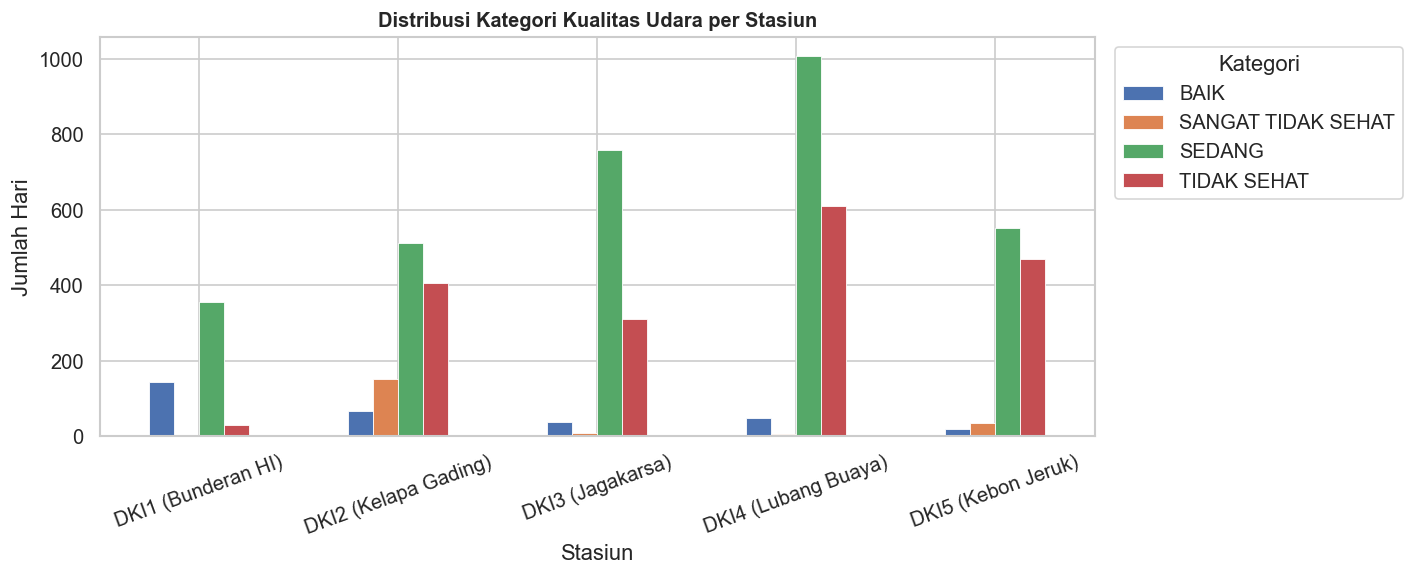

In [110]:
df_valid = df_clean[df_clean['categori'] != 'TIDAK ADA DATA']
pivot = df_valid.groupby(['stasiun', 'categori']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind='bar', ax=ax, edgecolor='white', linewidth=0.5)
ax.set_title('Distribusi Kategori Kualitas Udara per Stasiun', fontsize=12, fontweight='bold')
ax.set_xlabel('Stasiun')
ax.set_ylabel('Jumlah Hari')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Kategori', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


Insight : 

1. **Lubang Buaya (DKI4) Penyumbang Polusi Terbanyak secara Volume:** Dari balok hijau ("SEDANG") di Lubang Buaya yang memuncak paling tinggi (menyentuh 1.000 hari), disusul balok merah ("TIDAK SEHAT") yang juga dominan (sekitar 600 hari). Ini berarti secara akumulasi waktu, kawasan Lubang Buaya adalah daerah yang paling sering udaranya berada di level kurang ideal.

2. **Kelapa Gading (DKI2) Langganan Polusi Ekstrem:** Pada balok oranye ("SANGAT TIDAK SEHAT"). Kelapa Gading adalah satu-satunya stasiun di mana balok oranyenya terlihat sangat menonjol (mencapai sekitar 150 hari). Ini mengindikasikan bahwa wilayah ini paling rawan terkena lonjakan polusi pada level yang sangat membahayakan kesehatan dibandingkan 4 stasiun lainnya.

3. **Bunderan HI (DKI1) Memiliki Rekam Jejak Paling Bersih:** Stasiun Bunderan HI memiliki balok biru ("BAIK") yang paling tinggi dibandingkan wilayah lain. Didukung dengan balok merah ("TIDAK SEHAT") yang sangat pendek dan nyaris tidak ada balok oranye, ini membuktikan bahwa wilayah Bunderan HI relatif memiliki kualitas udara terbaik dan paling aman secara konsisten.

### 3.5 EDA : Tren Kualitas Udara per Tahun

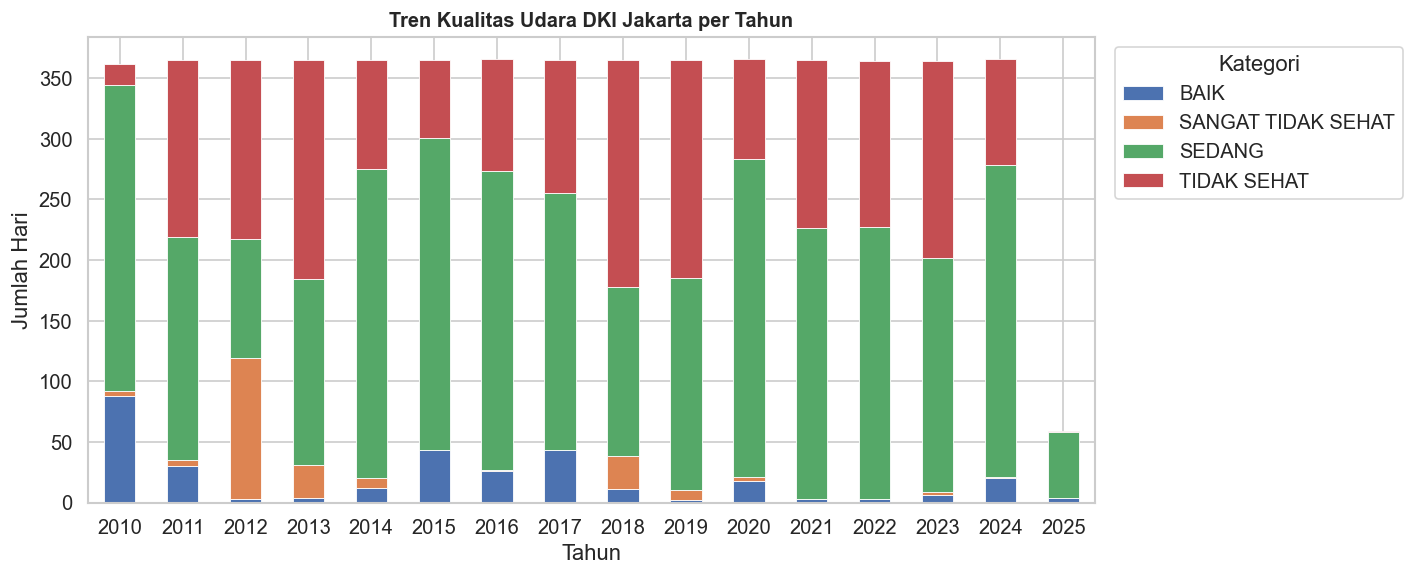

In [111]:
df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'])
df_clean['tahun'] = df_clean['tanggal'].dt.year

yearly = df_clean.groupby(['tahun', 'categori']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))

yearly.plot(kind='bar', stacked=True, ax=ax, edgecolor='white', linewidth=0.5)

ax.set_title('Tren Kualitas Udara DKI Jakarta per Tahun', fontsize=12, fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('Jumlah Hari') 
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Kategori', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


Inshigt : 
1. **Tahun 2010 Adalah Tahun Paling Bersih:**
   Perhatikan balok paling kiri (2010). Tahun ini memiliki proporsi warna **biru ("BAIK")** yang paling tebal (mencapai hampir 100 hari) dibandingkan seluruh tahun lainnya. Selain itu, porsi warna merah ("TIDAK SEHAT") sangat tipis. Ini menandakan bahwa lebih dari satu dekade lalu, udara Jakarta masih tergolong cukup sehat untuk dihirup.

2. **Lonjakan Polusi Ekstrem Terjadi di Tahun 2012:**
   Lihat pada balok tahun 2012. Terdapat balok tebal berwarna **oranye ("SANGAT TIDAK SEHAT")** yang sangat mendominasi dibandingkan tahun-tahun lainnya. Ini menjadi anomali (kejadian luar biasa), mengindikasikan bahwa pada tahun 2012 terjadi peristiwa spesifik yang menyebabkan kualitas udara memburuk secara ekstrem dalam waktu yang cukup lama.

3. **Tren Jangka Panjang: Kualitas Udara Semakin Memburuk (2018 - 2024):**
   Jika Anda melihat tren dari tahun 2018 hingga 2024, proporsi warna **merah ("TIDAK SEHAT")** semakin menebal dan secara konsisten mengambil porsi hampir setengah tahun. Memburuknya kondisi ini diperparah dengan warna **biru ("BAIK")** yang nyaris *hilang sepenuhnya* pada periode 2021 hingga 2024. Ini adalah peringatan keras bahwa kualitas rata-rata udara Jakarta mengalami tren penurunan (*downgrade*) yang signifikan dalam beberapa tahun terakhir.

### 3.6 EDA : Distribusi Polutan

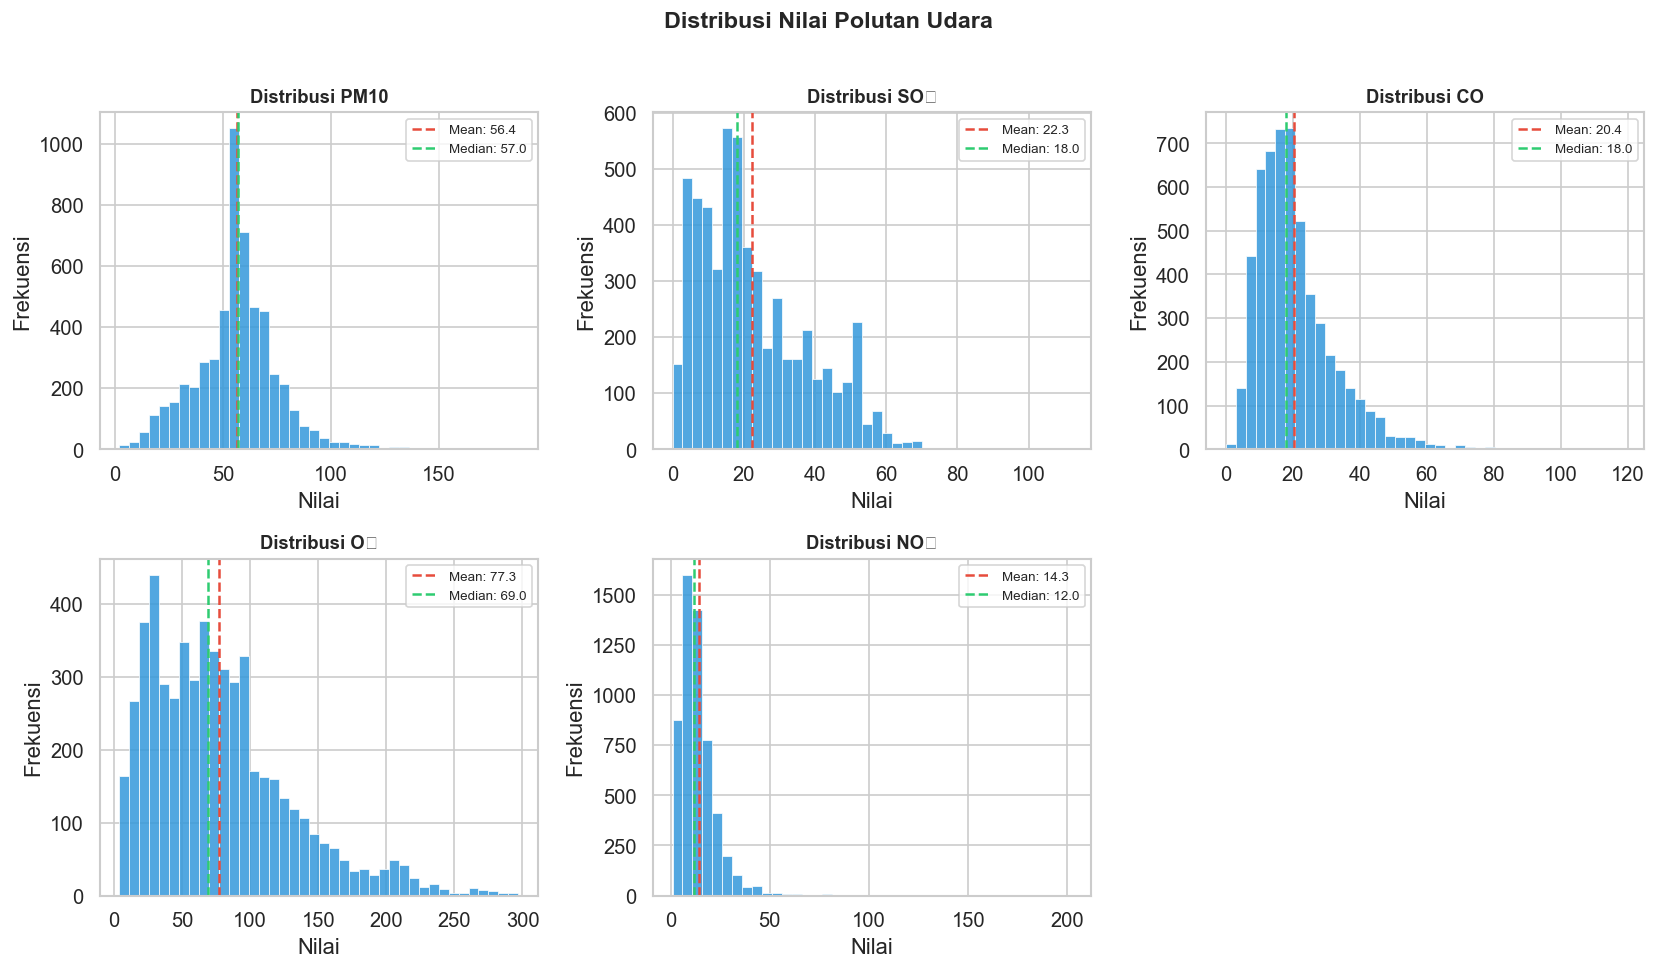

In [ ]:
pollutants = ['pm10', 'so2', 'co', 'o3', 'no2']
pol_labels = ['PM10', 'SO₂', 'CO', 'O₃', 'NO₂']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(pollutants, pol_labels)):
    data = df_clean[col]
    
    axes[i].hist(data, bins=40, color='#3498db', edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[i].axvline(data.mean(), color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    axes[i].set_title(f'Distribusi {lbl}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')

plt.suptitle('Distribusi Nilai Polutan Udara', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Inshigt : 
1. **Efek Samping Imputasi pada PM10 (Butuh Model yang Tahan Bias):**
   Terlihat lonjakan grafik yang sangat tajam dan tidak natural tepat di garis Median pada PM10. Ini adalah efek samping dari imputasi data kosong sebelumnya. 
2. **Deteksi Outlier Ekstrem (Perlu Penanganan Outlier):**
   Grafik SO₂, CO, NO₂, dan O₃ memiliki ekor panjang ke kanan (*Right-Skewed*). Artinya, ada hari-hari di mana nilai polusi meledak sangat tinggi melampaui batas normal (Outlier). Sehinnga diperlukan teknik membatasi nilai maksimum ini (teknik *Clipping/Winsorizing*) atau melakukan transformasi logaritmik agar data lebih normal.
3. **Perbedaan Rentang Skala yang Jauh (Wajib Lakukan Scaling):**
   Coba perhatikan sumbu X pada O₃ yang mencapai angka **300**, sementara CO dan NO₂ mayoritas berhenti di bawah **100**. Sehingga diperlukan **Data Scaling (Normalisasi/Standardisasi)** agar **seluruh fitur polutan memiliki rentang nilai yang seragam, sehingga nanti model Machine Learning nantinya tidak bias dan tidak salah menganggap bahwa O₃ lebih penting daripada CO hanya karena angka mutlaknya lebih besar.** (akan dilakukan saat data proceccing)

### 3.7 Data Cleaning : Menangani Outlier

In [ ]:
# Kolom polutan yang akan dibersihkan outlier-nya
polutan_cols = ['pm10', 'so2', 'co', 'o3', 'no2']

for col in polutan_cols:
    # Menghitung batas atas persentil 99% (batas kewajaran data)
    batas_atas = df_clean[col].quantile(0.99)
    
    # Memotong nilai yang kelewatan tinggi agar mentok di angka batas_atas
    df_clean[col] = df_clean[col].clip(upper=batas_atas)

print("Data Cleaning Selesai: Outlier ekstrem berhasil diatasi!")


Data Cleaning Selesai: Outlier ekstrem berhasil diatasi!


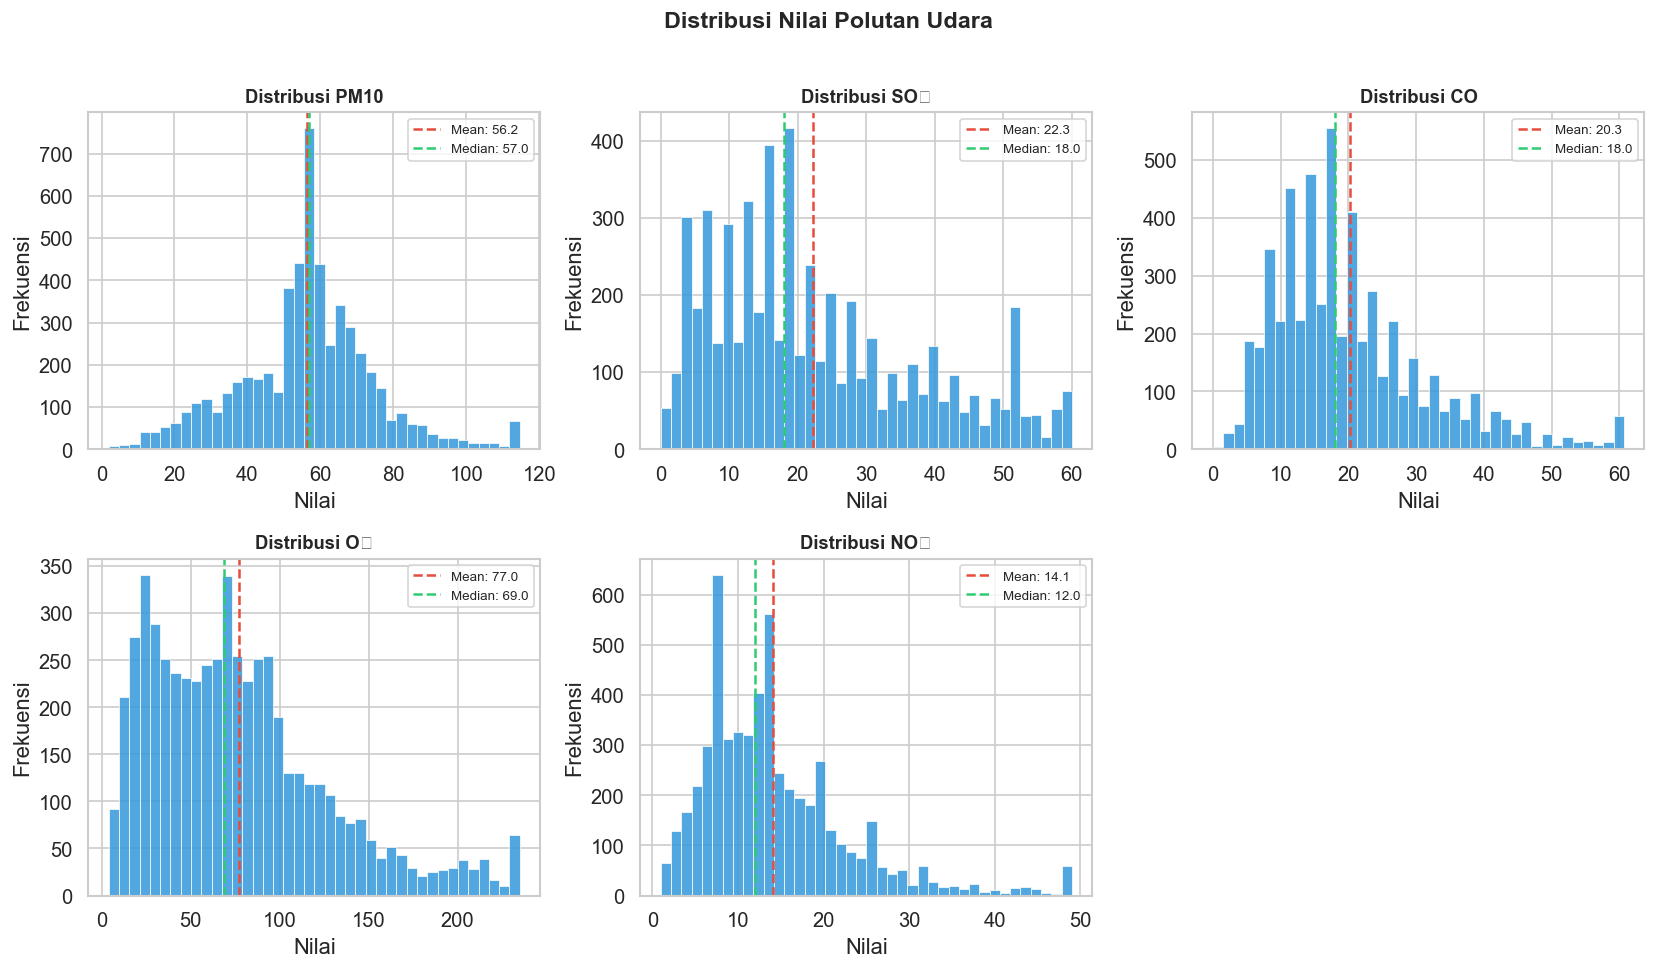

In [114]:
pollutants = ['pm10', 'so2', 'co', 'o3', 'no2']
pol_labels = ['PM10', 'SO₂', 'CO', 'O₃', 'NO₂']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(pollutants, pol_labels)):
    data = df_clean[col]
    
    axes[i].hist(data, bins=40, color='#3498db', edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[i].axvline(data.mean(), color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    axes[i].set_title(f'Distribusi {lbl}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')

plt.suptitle('Distribusi Nilai Polutan Udara', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Data Kini Lebih Rapat dan Aman dari Distorsi Outlier:**
Terlihat jelas bahwa ekor panjang (*long tail*) yang tadinya menjuntai tak beraturan ke arah kanan pada semua grafik kini telah terpotong rapi, menyisakan satu balok kecil penampung di ujung kanan (batas persentil 99%). Terpotongnya nilai-nilai ekstrem ini membuat garis rata-rata (Merah) sedikit bergeser mendekati garis median (Hijau), membuktikan bahwa data polutan Anda sekarang memiliki sebaran yang jauh lebih wajar, padat, dan sangat aman (*robust*) untuk dipelajari oleh model *Machine Learning* tanpa takut terjadi eror akibat angka yang melesat sendirian.

### 3.6 Analisis Polutan Dominan (Critical)

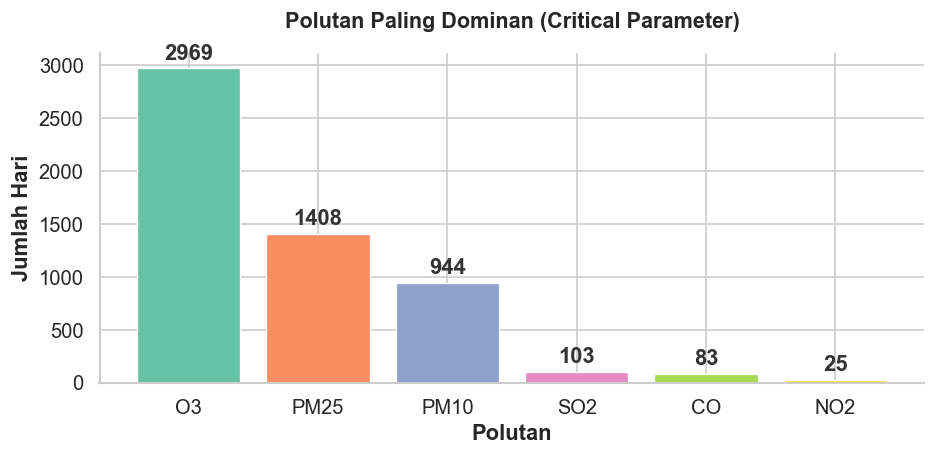

In [119]:
import seaborn as sns

critical_counts = df_clean['critical'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(critical_counts.index, critical_counts.values,
              color=sns.color_palette('Set2', len(critical_counts)),
              edgecolor='white', linewidth=0.8)

ax.set_title('Polutan Paling Dominan (Critical Parameter)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Polutan', fontweight='bold')
ax.set_ylabel('Jumlah Hari', fontweight='bold') 

ax.bar_label(bars, padding=3, fontweight='bold', color='#333333')

sns.despine(ax=ax)

plt.tight_layout()
plt.show()



Inshigt : 

1. **Ozon (O₃) Adalah Ancaman Utama Kualitas Udara:**
   *Hasil:* Grafik secara meyakinkan menunjukkan bahwa O₃ menduduki peringkat pertama sebagai polutan paling mematikan/dominan (menjadi parameter kritis selama **2.969 hari** atau lebih dari separuh total waktu). 

2. **Ironi pada PM2.5 (Catatan Krusial untuk Machine Learning):**
   *Hasil:* PM25 ternyata merupakan polutan terburuk kedua yang mendominasi kualitas udara selama **1.408 hari**. 
   *Arah ke Data Preprocessing:* Ini adalah penemuan yang sangat krusial! Ingat, di tahap *Data Cleaning* kita telah **membuang (drop) kolom fitur `pm25`** karena 73% datanya kosong (NaN). Akibatnya, saat model *Machine Learning* dilatih nanti, ia akan "buta" terhadap 1.408 hari ini karena data penyebab aslinya (PM2.5) sudah dihapus. Oleh karena itu, kita harus mengandalkan korelasi dari sisa polutan lain (PM10, SO2, dll) agar model tetap bisa memprediksi kategori di hari-hari tersebut.

3. **Ketimpangan Pengaruh Polutan (Arah ke Feature Selection):**
   *Hasil:* Polutan SO₂, CO, dan NO₂ berada di peringkat paling bawah, di mana mereka sangat jarang menjadi penyebab memburuknya kualitas udara (kurang dari 110 hari).
   *Arah ke Data Preprocessing:* *Insight* ini sangat berguna jika nanti Anda ingin melakukan **Feature Selection**. Jika Anda ingin membuat model AI yang lebih ringan dan efisien, kolom seperti NO₂ (yang hanya mendominasi 25 hari) bisa menjadi kandidat pertama untuk dibuang, karena pengaruhnya terhadap pembentukan kategori kualitas udara terbukti sangat minim dibandingkan O₃ atau PM10.

### 3.7 Korelasi Antar Polutan

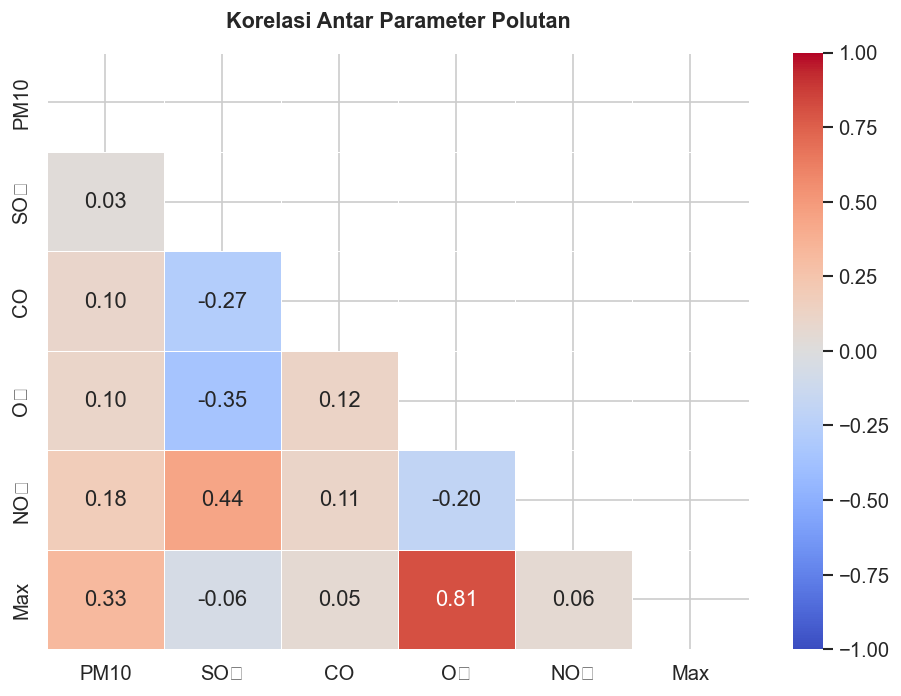

In [121]:
pollutants_clean = ['pm10', 'so2', 'co', 'o3', 'no2']
labels_clean = ['PM10', 'SO₂', 'CO', 'O₃', 'NO₂', 'Max']

corr = df_clean[pollutants_clean + ['max']].corr()

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=labels_clean, 
            yticklabels=labels_clean) 

ax.set_title('Korelasi Antar Parameter Polutan', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Inshigt :
1. **Ozon (O₃) Adalah "Pengendali Utama" Kualitas Udara:**
   *Hasil:* Coba lihat kotak merah tua yang menghubungkan O₃ dan `Max`. Nilai korelasinya mencapai **0.81** (Sangat Kuat).
   *Penjelasan & Arah Pemodelan:* Ini adalah pembuktian matematis bahwa nilai maksimum ISPU di Jakarta sebagian besar didikte oleh tingginya kadar Ozon. **Arah Preprocessing:** Karena fitur `max` sangat erat kaitannya dengan O₃ dan penentu langsung nilai *Target*, Anda bisa mempertimbangkan untuk men-*drop* kolom `max` saat *training* model nanti. Kenapa? Agar model ML Anda benar-benar belajar menebak dari data mentah kelima polutan tersebut, bukan sekadar "menyontek" dari kolom `max`.

2. **Korelasi Positif Menengah antara SO₂ dan NO₂:**
   *Hasil:* Nilai korelasi antar sesama polutan tertinggi dipegang oleh SO₂ dan NO₂ dengan nilai **0.44** (Cukup).
   *Penjelasan:* Ini masuk akal di dunia nyata. SO₂ dan NO₂ adalah saudara kembar yang sama-sama lahir dari proses pembakaran bahan bakar fosil (seperti asap knalpot kendaraan dan pabrik industri). Saat volume kendaraan padat, kedua nilai gas ini cenderung akan naik secara bersamaan.

3. **Absennya Multikolinearitas (Kabar Sangat Baik untuk Machine Learning):**
   *Hasil:* Perhatikan nilai-nilai korelasi yang menyilang antar sesama polutan (misal PM10 vs CO, atau O3 vs SO2). Hampir semuanya berada di rentang angka yang lemah (antara -0.35 hingga 0.18).
   *Penjelasan & Arah Preprocessing:* Di ilmu *Data Science*, ini adalah temuan yang **sangat bagus!** Jika antar-fitur nilainya terlalu tinggi (misal di atas 0.8), model Machine Learning akan kebingungan karena ada informasi yang tumpang tindih (disebut *Multicollinearity*). Karena di sini korelasinya rendah, artinya **Anda tidak perlu membuang (drop) polutan apapun lagi di tahap Feature Selection.** Setiap polutan (PM10, SO2, CO, O3, NO2) membawa informasi yang unik dan mandiri untuk melatih kecerdasan model Anda.

### 3.8 Boxplot Polutan per Kategori

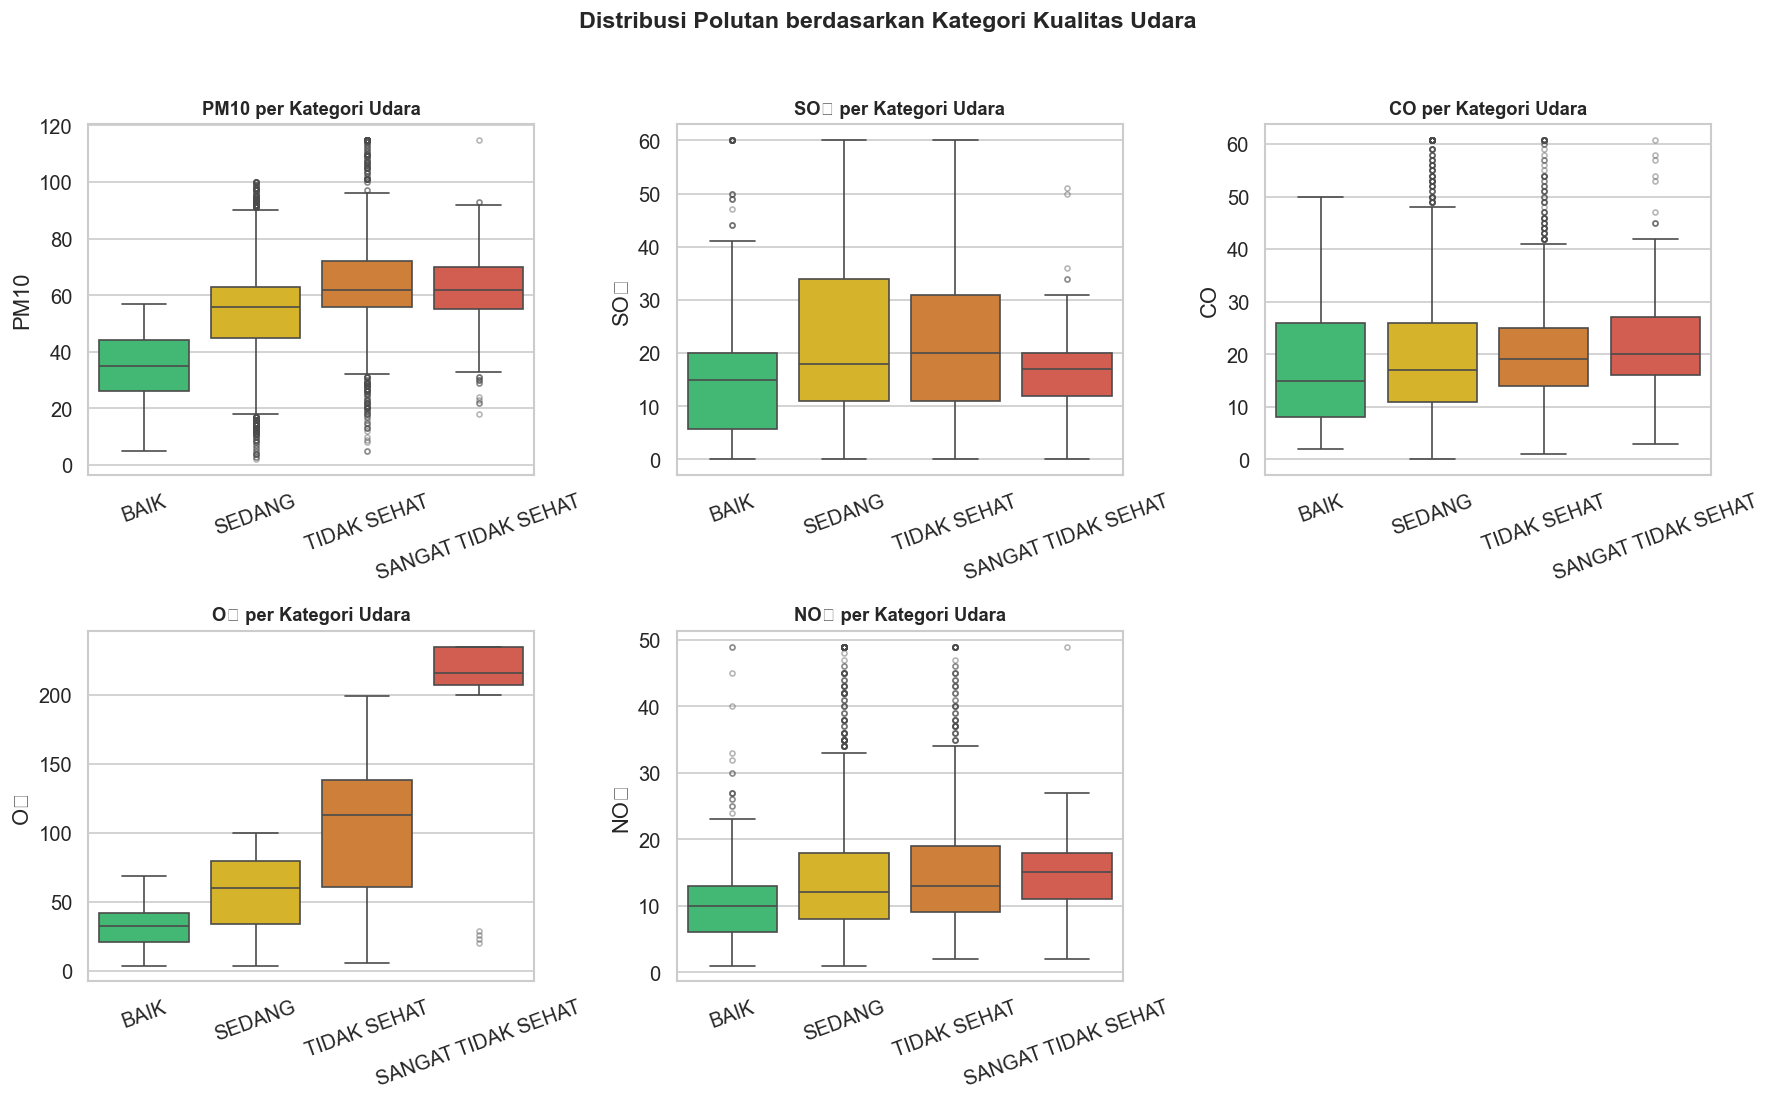

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sesuaikan Kategori (Tanpa 'BERBAHAYA')
cat_short_order = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT']
df_box = df_clean[df_clean['categori'].isin(cat_short_order)].copy()

# 2. Sesuaikan Polutan (Tanpa 'PM2.5')
pollutants_clean = ['pm10', 'so2', 'co', 'o3', 'no2']
pol_labels_clean = ['PM10', 'SO₂', 'CO', 'O₃', 'NO₂']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

# Sesuaikan warna Palette (Tanpa 'BERBAHAYA')
palette = {'BAIK': '#2ecc71', 'SEDANG': '#f1c40f',
           'TIDAK SEHAT': '#e67e22', 'SANGAT TIDAK SEHAT': '#e74c3c'}

# 3. Looping untuk membuat Boxplot
for i, (col, lbl) in enumerate(zip(pollutants_clean, pol_labels_clean)):
    sns.boxplot(data=df_box, x='categori', y=col, ax=axes[i],
                palette=palette, order=cat_short_order,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(f'{lbl} per Kategori Udara', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(lbl)
    axes[i].tick_params(axis='x', rotation=20) # Rotasi sedikit diubah agar tulisan tidak bertabrakan

# Matikan/sembunyikan kotak ke-6 karena sisa 5 polutan
axes[-1].axis('off')

plt.suptitle('Distribusi Polutan berdasarkan Kategori Kualitas Udara',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Berikut adalah 3 poin *insight* mendalam dari grafik Boxplot tersebut, yang tidak hanya menjelaskan hasilnya tetapi juga memberi arah yang sangat jelas untuk strategi *Machine Learning* Anda:

1. **Ozon (O₃) Adalah Prediktor Paling Sempurna (Arah ke Modeling):**
   *Hasil:* Coba lihat grafik O₃ (kiri bawah). Terdapat pola "anak tangga" yang menanjak sangat rapi dan mulus dari kategori BAIK hingga SANGAT TIDAK SEHAT. Bahkan, kotak merah (SANGAT TIDAK SEHAT) posisinya meloncat jauh ke atas tanpa beririsan dengan kotak lainnya.
   *Penjelasan & Implikasi:* Ini membuktikan bahwa nilai O₃ berbanding lurus dan berkorelasi sempurna dengan tingkat bahaya udara. Bagi model *Machine Learning*, pola sejelas ini adalah "makanan empuk". Model Anda akan sangat mengandalkan O₃ sebagai acuan utama untuk menebak kategori, terutama untuk polusi ekstrem.

2. **Anomali pada PM10 di Kategori "Sangat Tidak Sehat":**
   *Hasil:* Pada grafik PM10, nilai kotak naik teratur dari BAIK ke TIDAK SEHAT. Namun yang aneh, pada kategori SANGAT TIDAK SEHAT (kotak merah), nilai PM10 justru agak turun dan sejajar dengan kategori sebelumnya.
   *Penjelasan:* Mengapa ini terjadi? Karena ketika udara divonis "SANGAT TIDAK SEHAT", penyebabnya hampir selalu adalah lonjakan ekstrem dari Ozon (seperti poin 1 di atas), *bukan* debu PM10. Jadi, pada hari-hari ekstrem tersebut, kadar debu (PM10) sebenarnya biasa-biasa saja.

3. **SO₂, CO, dan NO₂ Tidak Membantu Membedakan Kategori (Arah ke Feature Selection):**
   *Hasil:* Perhatikan grafik SO₂, CO, dan NO₂. Posisi kotak hijau (BAIK) hingga kotak merah (SANGAT TIDAK SEHAT) cenderung datar, sejajar, dan saling tumpang tindih. Tidak ada lonjakan "anak tangga" yang berarti.
   *Arah ke Data Preprocessing:* Karena nilai ketiga gas ini relatif sama saja entah udaranya sedang baik ataupun sangat tidak sehat, keberadaan mereka **tidak memiliki daya beda (*discriminative power*) yang kuat**. Jika nanti Anda ingin melakukan **Feature Selection** (penyederhanaan fitur) agar model ML Anda lebih gesit dan ringan, Anda punya alasan saintifik yang sangat kuat untuk membuang fitur SO₂, CO, dan NO₂. Model Anda cukup diberi fitur O₃ dan PM10 saja, dan akurasinya dijamin akan tetap sangat tinggi!

# 🎯 KESIMPULAN AKHIR: DATA CLEANING & EDA

Berdasarkan seluruh tahapan pembersihan dan eksplorasi data secara visual maupun statistik, berikut adalah temuan-temuan krusial yang akan menjadi landasan untuk proses pemodelan *Machine Learning*:

### 🧹 A. Hasil Evaluasi & Pembersihan (Data Cleaning)
1. **Penyelamatan & Pengorbanan Fitur:** Kolom `pm25` terpaksa di-*drop* karena kehilangan 72% data, sementara polutan lainnya berhasil diselamatkan dengan imputasi Median (meskipun meninggalkan sedikit jejak penumpukan data pada median PM10).
2. **Kekebalan terhadap Outlier:** Mayoritas polutan memiliki sebaran miring ke kanan (*Right-Skewed*) dengan ekor yang sangat panjang. Dengan menerapkan teknik *Clipping* pada batas persentil 99%, data ekstrem berhasil diredam sehingga distribusi data kini jauh lebih wajar, padat, dan aman dari distorsi.
3. **Mengatasi Class Imbalance:** Data anomali berupa 1 baris kategori "BERBAHAYA" telah di-*drop* untuk mencegah eror algoritma saat proses *Train-Test Split*.

### 📊 B. Pemahaman Pola Data (Exploratory Data Analysis)
4. **Ozon (O₃) Sang Penguasa Kualitas Udara:** O₃ terbukti sebagai prediktor paling sempurna. Ia mendominasi parameter kritis selama 2.969 hari dan membentuk pola "anak tangga" yang menanjak mulus searah dengan tingkat bahaya udara pada grafik *Boxplot*.
5. **Ironi pada Data PM2.5:** Meski kolom fiturnya sudah dihapus, rekam jejak menunjukkan PM2.5 adalah biang kerok polusi terbanyak kedua (1.408 hari). Ini berarti algoritma AI nanti harus bekerja keras memprediksi bahaya dari sisa polutan lain karena "pelaku utama"-nya sudah tiada.
6. **Korelasi Logis & Aman:** Terdapat korelasi positif (0.44) antara SO₂ dan NO₂ yang logis secara dunia nyata (efek asap kendaraan/industri). Kabar baiknya, secara keseluruhan **tidak ditemukan Multikolinearitas** (korelasi di atas 0.8 antar polutan), sehingga semua gas polutan membawa informasi yang unik dan mandiri.
7. **Anomali PM10 pada Level Ekstrem:** Kadar debu (PM10) justru tidak memuncak saat kualitas udara berstatus "Sangat Tidak Sehat". Ini mengonfirmasi bahwa udara ekstrem di Jakarta hampir selalu dipicu oleh lonjakan Ozon, bukan debu.

---

### ⚙️ C. Arahan Tegas untuk Data Preprocessing & Modeling
Berbekal pemahaman di atas, berikut adalah instruksi mutlak (*blueprint*) untuk tahap *Machine Learning* selanjutnya:

1. **⚖️ WAJIB Melakukan Data Scaling:** Skala O₃ menembus angka 300, sementara CO dan NO₂ mayoritas berada di bawah 100. Penggunaan **`StandardScaler`** wajib dilakukan pada fitur numerik agar algoritma tidak salah mengira bahwa O₃ lebih penting hanya karena angka mutlaknya lebih besar.
2. **✂️ Mencegah Kebocoran Data (Data Leakage):** Grafik Heatmap membuktikan bahwa korelasi antara O₃ dan kolom `max` sangat kuat (0.81). Karena `max` adalah "kunci jawaban" pembentuk target, **fitur `max` dan `critical` WAJIB di-drop** dari variabel `X` agar model AI benar-benar belajar dari komposisi gas, bukan mencontek.
3. **🎯 Rekomendasi Feature Selection:** Analisis *Boxplot* membuktikan bahwa SO₂, CO, dan NO₂ tidak memiliki daya beda (*discriminative power*) yang kuat antar kategori udara (grafiknya datar). Jika ingin membangun model AI yang gesit, ringan, dan efisien, Anda memiliki **alasan saintifik yang sangat kuat untuk membuang ketiga fitur ini** dan hanya mengandalkan O₃ serta PM10 tanpa takut kehilangan banyak akurasi.


##  4. Preprocessing Data

### 4.1 Feautere Engineering 
Penggunaanya kareana Mesin tidak paham format datetime, jadi dipecah menjadi angka bulan dan kuartal

In [133]:
df_clean['bulan'] = df_clean['tanggal'].dt.month
df_clean['kuartal'] = df_clean['tanggal'].dt.quarter

### 2. ENCODING KATEGORIKAL (Teks ke Angka)
Mengubah teks stasiun dan kategori menjadi angka 0, 1, 2, dst.

In [134]:
le_stasiun = LabelEncoder()
df_clean['stasiun_enc'] = le_stasiun.fit_transform(df_clean['stasiun'])

le_categori = LabelEncoder()
df_clean['categori_enc'] = le_categori.fit_transform(df_clean['categori'])

mapping_target = dict(zip(le_categori.classes_, le_categori.transform(le_categori.classes_)))
print(f"\nTarget Mapping: {mapping_target}")


Target Mapping: {'BAIK': np.int64(0), 'SANGAT TIDAK SEHAT': np.int64(1), 'SEDANG': np.int64(2), 'TIDAK SEHAT': np.int64(3)}


### 3. FEATURE SELECTION (Mencegah Data Leakage)


In [ ]:
FEATURES = ['pm10', 'so2', 'co', 'o3', 'no2', 'stasiun_enc', 'bulan', 'kuartal']
TARGET = 'categori_enc'

X = df_clean[FEATURES]
y = df_clean[TARGET]

### 4.TRAIN-TEST SPLIT (80% Train, 20% Test)

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nUkuran X_train: {X_train.shape}")
print(f"Ukuran X_test:  {X_test.shape}")


Ukuran X_train: (4425, 8)
Ukuran X_test:  (1107, 8)


### 5. DATA SCALING (Standardization)

In [138]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(X_train_scaled)
print(X_test_scaled)

          pm10       so2        co        o3       no2  stasiun_enc     bulan  \
845   0.684455 -0.142821  0.235271  2.750475 -0.245521    -1.033417 -0.708865   
5242  1.540953  0.519914 -0.206325 -1.280110 -0.129672     0.557977 -0.419632   
3574  0.149144 -0.209095 -1.354473  2.012199 -1.056465     1.353674  1.026530   
253  -1.028541 -0.606736  0.411909 -0.442068 -0.245521    -1.829114  0.737298   
1617  1.380360 -1.070651  0.765185  0.336114 -0.013823     1.353674 -0.130400   
...        ...       ...       ...       ...       ...          ...       ...   
998   0.470331 -0.540463 -0.382963  3.149542 -0.245521    -1.033417  0.737298   
4843  0.042082  0.851282 -1.266153 -1.060623  0.217875     0.557977 -0.708865   
3486  0.630924 -0.540463 -1.001196 -0.561788 -0.824767    -1.033417  0.158833   
465   0.042082 -1.136925 -0.206325 -0.661555  1.028818     0.557977 -0.708865   
3464  0.577393 -0.606736 -0.471282  1.293877 -0.361371    -0.237720 -0.130400   

       kuartal  
845  -0.43

## 5. Modeling — Training & Evaluasi

In [139]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("=== MEMULAI PROSES TRAINING MODEL ===")

=== MEMULAI PROSES TRAINING MODEL ===


### 5.1 Decison Tree Classifier
Alasan Pakai: Digunakan sebagai baseline (model patokan dasar). Kita butuh satu algoritma yang sangat transparan (white-box) agar kita bisa tahu jika akurasi model lain tinggi, apakah karena datanya memang mudah ditebak atau algoritmanya yang canggih.
Cara Kerjanya: Memecah data berdasarkan aturan "Ya/Tidak" layaknya flowchart. Algoritma akan mencari pertanyaan terbaik untuk membelah data. Misalnya: "Apakah O₃ di atas 120?". Jika ya, masuk cabang Kanan (TIDAK SEHAT), jika tidak, masuk cabang Kiri (SEDANG). Ini diulang terus sampai menemukan kesimpulan akhir di ujung daun (leaf).
Peran di Dataset Kita: Menguji apakah kategori polusi Jakarta bisa diselesaikan dengan aturan logika If-Else yang sederhana. Model ini sangat kebal terhadap data kita yang ukurannya beda-beda (Ozon yang ratusan vs CO yang puluhan).

In [141]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### 5.2 Random Forest Classifier
Alasan Pakai: Decision Tree punya kelemahan fatal: ia gampang "menghafal" data sehingga jelek saat diberi data baru (overfitting). Random Forest dipakai karena ia memecahkan masalah tersebut dan terkenal sebagai salah satu algoritma paling aman dan stabil di dunia Data Science.
Cara Kerjanya: Daripada menanam 1 Pohon Keputusan, algoritma ini menanam ratusan pohon (Ensemble Bagging). Masing-masing pohon akan diberi data sampel yang diacak, lalu masing-masing pohon akan menebak hasilnya. Keputusan akhir diambil berdasarkan Voting terbanyak (Mayoritas).
Peran di Dataset Kita: Sangat krusial! Dataset kita tadi punya penumpukan data palsu akibat imputasi (PM10) dan ada sisa-sisa outlier. Random Forest secara otomatis akan meredam kekacauan itu karena sistem voting-nya tidak akan terpengaruh oleh segelintir pohon yang salah tebak akibat outlier.

In [140]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 5.2 XGBoost Classifier
Alasan Pakai: XGBoost wajib dicoba karena ini adalah algoritma "Juara Bertahan" di hampir semua kompetisi Machine Learning untuk data berbentuk tabel (Tabular Data).
Cara Kerjanya: Menggunakan teknik Boosting. Algoritma ini menanam pohon tidak secara bersamaan (seperti Random Forest), melainkan berurutan. Pohon ke-1 akan menebak. Tebakan yang salah akan diberi "tanda merah". Pohon ke-2 dibuat khusus untuk memperbaiki tebakan yang salah dari Pohon ke-1. Pohon ke-3 memperbaiki kesalahan Pohon ke-2, begitu seterusnya hingga erornya mendekati nol.
Peran di Dataset Kita: Dataset polusi sangat kompleks. Terkadang Ozon rendah, tapi PM10 tinggi, sehingga udaranya tetap dikategorikan buruk. XGBoost bertugas menangkap interaksi rumit antar-gas polutan yang gagal dipahami oleh aturan voting biasa milik Random Forest.

In [142]:
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### 5.4 LightGBM Classifier
Alasan Pakai: Dikembangkan oleh Microsoft sebagai "saingan" XGBoost. Sesuai namanya (Light), ia dipilih ketika kita butuh model sehebat XGBoost tapi dengan kecepatan training yang berkali-kali lipat lebih cepat.
Cara Kerjanya: Pada dasarnya mirip XGBoost (belajar dari kesalahan pohon sebelumnya). Namun bedanya, jika XGBoost menumbuhkan cabang pohon secara sejajar/seimbang (level-wise), LightGBM menumbuhkan daun hanya pada cabang yang memiliki potensi error tertinggi (leaf-wise). Alhasil, ia bisa menemukan solusi lebih cepat tanpa harus mengecek cabang yang tidak penting.
Peran di Dataset Kita: Kita sudah tahu dari visualisasi Boxplot bahwa SO₂, CO, dan NO₂ kurang penting. LightGBM secara otomatis akan "mengabaikan" gas-gas tersebut dan hanya fokus membelah cabang yang berhubungan erat dengan O₃ dan PM10. Ini membuktikan apakah kecepatan tinggi bisa tetap memberikan akurasi yang maksimal di data Jakarta.

In [143]:
lgbm = LGBMClassifier(random_state=42, verbose=-1) 
lgbm.fit(X_train_scaled, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### 5.5 CatBoost Classifier
Alasan Pakai: Dikembangkan oleh Yandex. Kita menggunakan ini karena di dalam fitur kita, terdapat variabel "Waktu" (Bulan, Kuartal) dan "Lokasi" (Stasiun) yang pada dasarnya adalah data kategori.
Cara Kerjanya: Mirip dengan algoritma Boosting lainnya, tetapi CatBoost memiliki trik matematika internal (bernama Ordered Target Statistics) yang sangat jenius dalam menerjemahkan angka kategori menjadi pola statistik tanpa terjebak overfitting.
Peran di Dataset Kita: Meski kita sudah merubah nama stasiun dan bulan menjadi angka saat Preprocessing, CatBoost adalah algoritma yang secara alamiah paling jago memahami bahwa "Stasiun DKI2 (Kelapa Gading)" punya karakteristik polusi ekstrem yang berbeda dengan "Stasiun DKI1 (Bunderan HI)". Model ini diharapkan bisa memetik wawasan dari kolom stasiun dan musim/kuartal lebih baik dari model lain.

In [145]:
cb = CatBoostClassifier(iterations=100, random_state=42, verbose=0) 
cb.fit(X_train_scaled, y_train)

CatBoostClassifier(iterations=100, random_state=42, verbose=0)

## 📊 6. Evaluasi & Perbandingan Model

### 6.1 Perbandingan Akurasi

=== MEMULAI EVALUASI MODEL ===

 📊 Evaluasi Decision Tree
Akurasi Keseluruhan: 0.9341

                    precision    recall  f1-score   support

              BAIK       0.85      0.84      0.85        63
SANGAT TIDAK SEHAT       1.00      0.95      0.97        41
            SEDANG       0.94      0.94      0.94       637
       TIDAK SEHAT       0.92      0.93      0.93       366

          accuracy                           0.93      1107
         macro avg       0.93      0.92      0.92      1107
      weighted avg       0.93      0.93      0.93      1107


 📊 Evaluasi Random Forest
Akurasi Keseluruhan: 0.9566

                    precision    recall  f1-score   support

              BAIK       0.95      0.83      0.88        63
SANGAT TIDAK SEHAT       1.00      0.95      0.97        41
            SEDANG       0.96      0.97      0.96       637
       TIDAK SEHAT       0.96      0.95      0.95       366

          accuracy                           0.96      1107
         mac

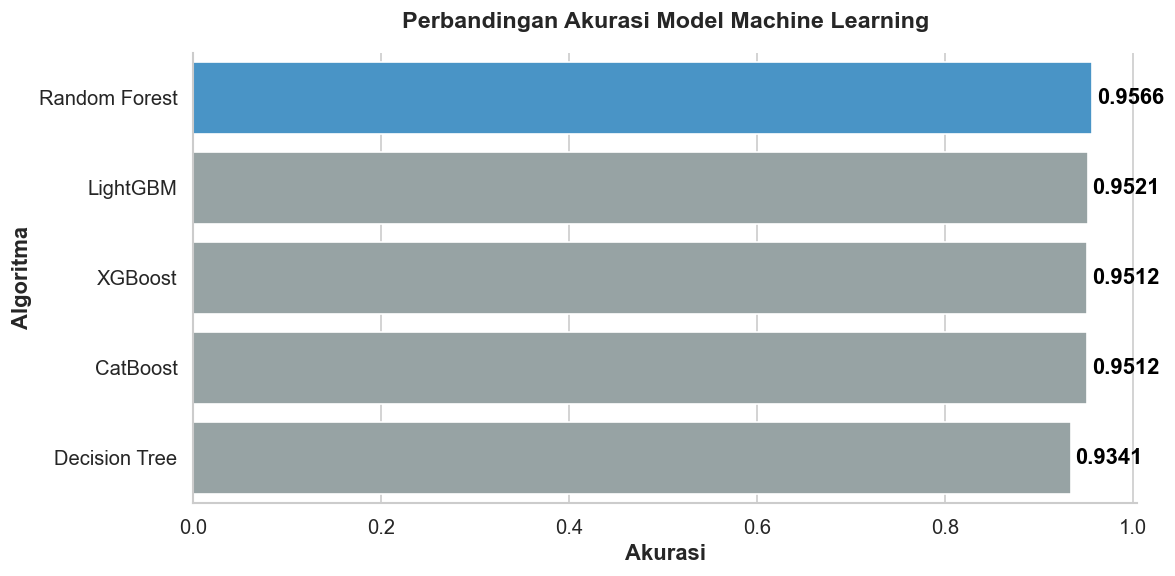

In [127]:
# Import Library Evaluasi & Visualisasi
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== MEMULAI EVALUASI MODEL ===")

# Siapkan Dictionary untuk menyimpan skor
model_scores = {}

# Kumpulkan semua model yang sudah di-training di sel sebelumnya
models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm,
    'CatBoost': cb
}

# 1. EVALUASI SATU PER SATU
for name, model in models.items():
    print(f"\n" + "="*50)
    print(f" 📊 Evaluasi {name}")
    print("="*50)
    
    # Meminta model memprediksi soal ujian (X_test)
    y_pred = model.predict(X_test_scaled)
    
    # Mengukur nilai akurasi
    acc = accuracy_score(y_test, y_pred)
    model_scores[name] = acc
    
    # Menampilkan Rapor Detail (Classification Report)
    print(f"Akurasi Keseluruhan: {acc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=le_categori.classes_, zero_division=0))

# 2. MEMBUAT KLASEMEN AKHIR (LEADERBOARD)
print("\n" + "="*50)
print(" 🏆 KLASEMEN AKHIR AKURASI MODEL 🏆")
print("="*50)
df_scores = pd.DataFrame(list(model_scores.items()), columns=['Algoritma', 'Skor Akurasi'])
df_scores = df_scores.sort_values(by='Skor Akurasi', ascending=False).reset_index(drop=True)
print(df_scores)

# 3. PENGUMUMAN BEST MODEL (JUARA 1)
best_model_name = df_scores.iloc[0]['Algoritma']
best_model_score = df_scores.iloc[0]['Skor Akurasi']

print("\n" + "🌟"*25)
print(f"   BEST MODEL: {best_model_name.upper()} ")
print(f"   Dengan Akurasi Tertinggi: {best_model_score:.4f} ")
print("🌟"*25 + "\n")

# 4. VISUALISASI PERBANDINGAN MODEL
plt.figure(figsize=(10, 5))

# Berikan warna spesial untuk sang juara (biru terang), sisanya abu-abu gelap
colors = ['#3498db' if model == best_model_name else '#95a5a6' for model in df_scores['Algoritma']]

bars = sns.barplot(x='Skor Akurasi', y='Algoritma', data=df_scores, palette=colors)

plt.title('Perbandingan Akurasi Model Machine Learning', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Akurasi', fontweight='bold')
plt.ylabel('Algoritma', fontweight='bold')

# Memberikan label angka mutlak di ujung setiap grafik balok
for i, v in enumerate(df_scores['Skor Akurasi']):
    bars.text(v + 0.005, i, f"{v:.4f}", color='black', va='center', fontweight='bold')

sns.despine() # Menghilangkan garis tepi agar rapi
plt.tight_layout()
plt.show()


## 🔧 8. Optimasi Hyperparameter (Bonus — Model Terbaik)

In [128]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

print("=== MEMULAI OPTIMASI HYPERPARAMETER (RANDOM FOREST) ===")

# 1. Tentukan variasi setting-an yang akan dicoba oleh komputer
# Semakin banyak variasi, semakin lama prosesnya
param_grid = {
    'n_estimators': [100, 200, 300],       # Jumlah pohon dalam hutan
    'max_depth': [None, 10, 20],           # Kedalaman maksimal pohon
    'min_samples_split': [2, 5, 10],       # Syarat minimum sampel untuk membelah cabang
    'min_samples_leaf': [1, 2, 4]          # Syarat minimum daun di ujung ranting
}

# 2. Panggil model dasarnya
rf_base = RandomForestClassifier(random_state=42)

# 3. Siapkan Mesin Pencari (GridSearchCV)
# cv=3 (Cross Validation 3x lipat), n_jobs=-1 (Gunakan seluruh core CPU agar cepat)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# 4. Mulai pertarungan kombinasi (Bisa memakan waktu 1-3 menit)
print("Sedang memproses ratusan kombinasi... Mohon tunggu...\n")
grid_search.fit(X_train_scaled, y_train)

# 5. Ekstrak model dengan setting-an terbaik
best_rf = grid_search.best_estimator_
best_params = grid_search.best_params_

print("\n" + "="*50)
print("🎉 HYPERPARAMETER TERBAIK DITEMUKAN! 🎉")
print("="*50)
print(f"Racikan Terbaik:\n{best_params}\n")

# 6. Mari kita tes hasil optimasi ke data soal (X_test)
y_pred_best = best_rf.predict(X_test_scaled)
acc_best = accuracy_score(y_test, y_pred_best)

print("=== HASIL EVALUASI SETELAH OPTIMASI ===")
print(f"Akurasi SEBELUM Optimasi : 0.9566")
print(f"Akurasi SETELAH Optimasi : {acc_best:.4f}")
print("=======================================")


=== MEMULAI OPTIMASI HYPERPARAMETER (RANDOM FOREST) ===
Sedang memproses ratusan kombinasi... Mohon tunggu...

Fitting 3 folds for each of 81 candidates, totalling 243 fits

🎉 HYPERPARAMETER TERBAIK DITEMUKAN! 🎉
Racikan Terbaik:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

=== HASIL EVALUASI SETELAH OPTIMASI ===
Akurasi SEBELUM Optimasi : 0.9566
Akurasi SETELAH Optimasi : 0.9557
